# Computer Book B: Normal distributions

These series of codes, illustrate using python, the various exercises from the OU course M248 Analysing Data. The exercises were originally written to be carried out using Minitab statistical software but those exercises have been re-done in Python below

**Background and relevant equations**

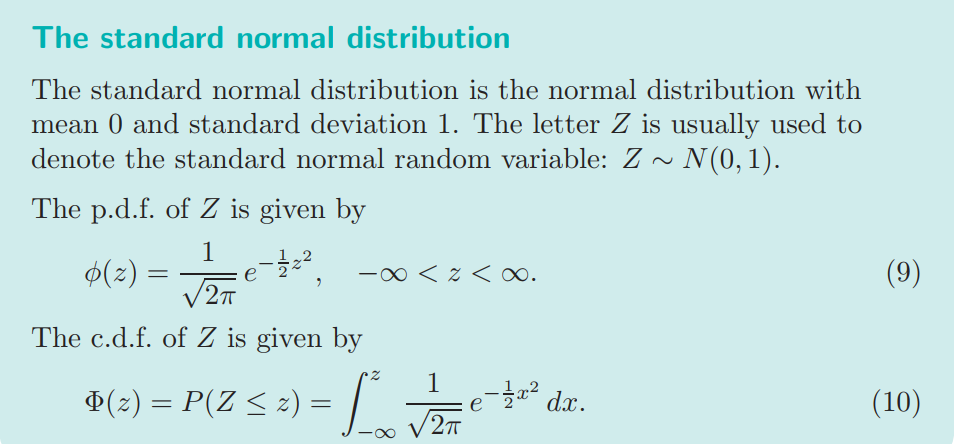

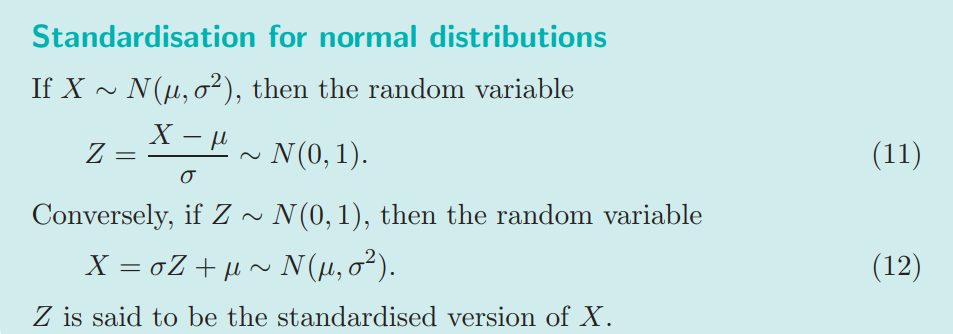

## Computer activity 1: Chest measurements of Scottish soldiers

In Unit 6, a normal distribution with mean 40 and standard deviation 2 was used to model the variation in the chest measurements (in inches) of Scottish soldiers in the nineteenth century. In this activity, you will use Minitab to calculate several probabilities for this distribution.

Recall from Computer Book A, that values of the c.d.f. are found using Cumulative probability, and quantiles are found using Inverse
cumulative probability. 

You will need to use Cumulative probability to answer parts (a) and (b) below, and Inverse cumulative probability to answer parts (c) and (d).

(a) Use Minitab to calculate the proportion of Scottish soldiers who, according to this model, had chests measuring between 37 and 42 inches inclusive.<br>
(b) According to this model, what proportion of Scottish soldiers had chest measurements greater than 43 inches?<br>
(c) According to this model, below what value were the chest measurements of only 2.5% of Scottish soldiers?<br>
(d) What chest measurement was exceeded by only 5% of Scottish soldiers according to this model?<br>

### The proportion of Scottish soldiers who, according to this model, had chests measuring between 37 and 42 inches inclusive.

Essentially the computation in Python is described by the formula below which is a way of standadising data which comes from a normal distribution (or a normally distributed population). The standardisation not only allows for comparisons across different values of a random variable $X$ but also allows for the calculation of probabilities.

The $z$ score represents the so called standard deviation the observed value is from the mean.

$z = \frac{X - \mu}{\sigma}$

The lower and upper $z$ scores should be computed and the differences found. Since the area on the normal probability distribution equals 1 the difference between the upper and lower $z$ gives the proportion of Scottish soldiers. The reason the upper and lower $z$ values can be substracted in such a way is that the normal probability curve is a Cummulitative Distribution Curve c.d.f.

Proportion between 37 and 42 inches: 0.7745 (77.45%)


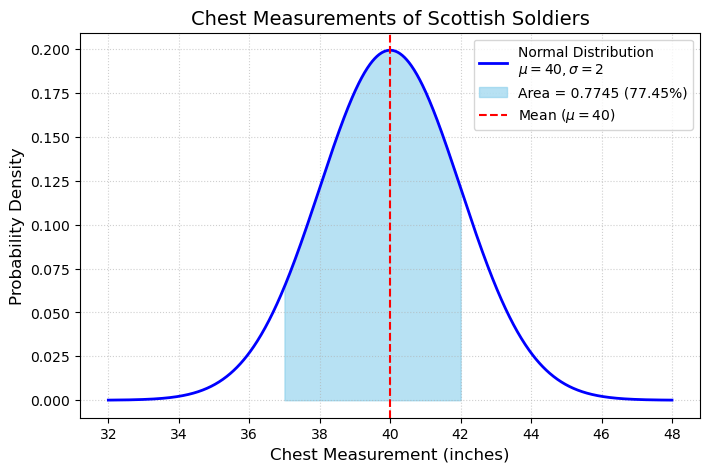

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given parameters
mu = 40        # Mean chest size (in inches)
sigma = 2      # Standard deviation (in inches)
lower = 37     # Lower bound
upper = 42     # Upper bound

# Step 1: Calculate the proportion using the Cumulative Distribution Function (CDF) - Z-score calculation
p_lower = stats.norm.cdf(lower, loc=mu, scale=sigma)
p_upper = stats.norm.cdf(upper, loc=mu, scale=sigma)
proportion = p_upper - p_lower

print(f"Proportion between {lower} and {upper} inches: {proportion:.4f} ({proportion * 100:.2f}%)")

# Step 2: Plot the probability distribution
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Normal Distribution\n$\\mu={mu}, \\sigma={sigma}$', color='blue', linewidth=2)

# Shade the region between 37 and 42 inches
x_shade = np.linspace(lower, upper, 500)
y_shade = stats.norm.pdf(x_shade, loc=mu, scale=sigma)
plt.fill_between(x_shade, y_shade, color='skyblue', alpha=0.6, label=f'Area = {proportion:.4f} ({proportion * 100:.2f}%)')

# Add labels and styling
plt.title('Chest Measurements of Scottish Soldiers', fontsize=14)
plt.xlabel('Chest Measurement (inches)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(mu, color='red', linestyle='--', label=f'Mean ($\\mu = {mu}$)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

#### Commentary

The normal distribution model shows that the proportion of Scottish soldiers that will have chest size between 37 and 42 inches i.e. $P(37 \le X \le 42)$ is roughly around 77.45% i.e. that should be the proportion in a given population.

### The proportion of Scottish soldiers who had chest measurements greater than 43 inches

Proportion greater than 43 inches: 0.0668 (6.68%)


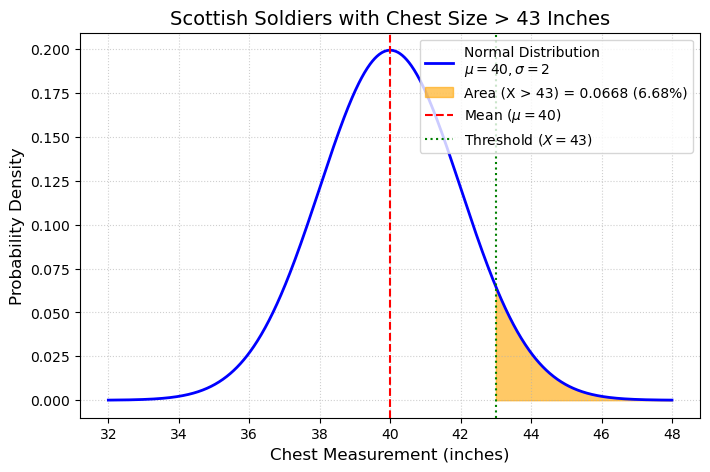

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given parameters
mu = 40        # Mean chest size (in inches)
sigma = 2      # Standard deviation (in inches)
threshold = 43 # Chest size threshold

# Step 1: Calculate the proportion using the Survival Function (1 - CDF)
proportion = stats.norm.sf(threshold, loc=mu, scale=sigma)
# Alternatively: proportion = 1 - stats.norm.cdf(threshold, loc=mu, scale=sigma)

print(f"Proportion greater than {threshold} inches: {proportion:.4f} ({proportion * 100:.2f}%)")

# Step 2: Plot the probability distribution
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Normal Distribution\n$\\mu={mu}, \\sigma={sigma}$', color='blue', linewidth=2)

# Shade the region greater than 43 inches
x_shade = np.linspace(threshold, mu + 4 * sigma, 500)
y_shade = stats.norm.pdf(x_shade, loc=mu, scale=sigma)
plt.fill_between(x_shade, y_shade, color='orange', alpha=0.6, label=f'Area (X > {threshold}) = {proportion:.4f} ({proportion * 100:.2f}%)')

# Add labels and styling
plt.title('Scottish Soldiers with Chest Size > 43 Inches', fontsize=14)
plt.xlabel('Chest Measurement (inches)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(mu, color='red', linestyle='--', label=f'Mean ($\\mu = {mu}$)')
plt.axvline(threshold, color='green', linestyle=':', label=f'Threshold ($X = {threshold}$)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

#### Commentary

The normal distribution model shows that the proportion of Scottish soldiers that will have chest size greater than 37 inches i.e. $P(Z > 1.5) = 1 - 0.9332 = 0.0668$ is around 6.68% which is 1.5 standard deviations (the $z$ score) from the mean

### Below what value were the chest measurements of only 2.5% of Scottish soldiers?

This is a case of doing the reverse of questions a) and b). Questions a) and b) calculations gave the percentages of the observable data by looking up the calculated $z$ score. Now by looking up the percentages in the probabilities for standard normal distribution table to retrieve the $z$ score it is possible to use and re-arrange the $z$ score equation above to calculate the actual observed value $X$ given the constraints of the normal distribution with mean 40 and standard deviation 2.

The re-arrange $z$ score equation then becomes: 

$X = \mu + z \cdot \sigma$

Chest measurement for the lowest 2.5%: 36.08 inches


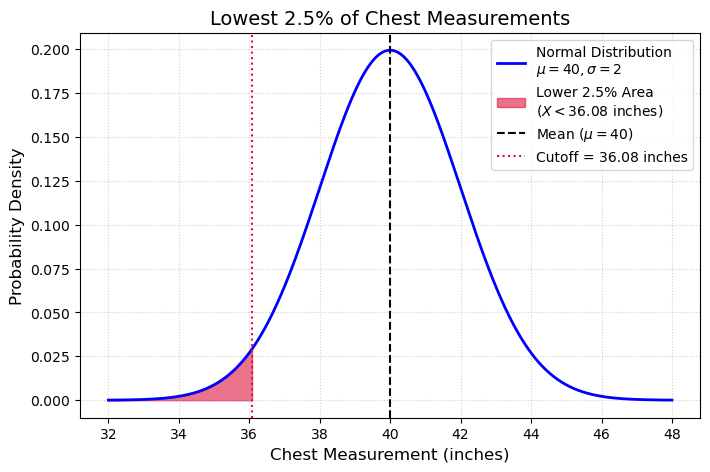

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given parameters
mu = 40          # Mean chest size (in inches)
sigma = 2        # Standard deviation (in inches)
percentile = 0.025 # 2.5%

# Step 1: Calculate the chest measurement using the Percent Point Function (PPF / inverse CDF)
cutoff_value = stats.norm.ppf(percentile, loc=mu, scale=sigma)

print(f"Chest measurement for the lowest {percentile * 100}%: {cutoff_value:.2f} inches")

# Step 2: Plot the probability distribution
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Normal Distribution\n$\\mu={mu}, \\sigma={sigma}$', color='blue', linewidth=2)

# Shade the lower 2.5% tail
x_shade = np.linspace(mu - 4 * sigma, cutoff_value, 500)
y_shade = stats.norm.pdf(x_shade, loc=mu, scale=sigma)
plt.fill_between(x_shade, y_shade, color='crimson', alpha=0.6, label=f'Lower 2.5% Area\n($X < {cutoff_value:.2f}$ inches)')

# Add labels and styling
plt.title('Lowest 2.5% of Chest Measurements', fontsize=14)
plt.xlabel('Chest Measurement (inches)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(mu, color='black', linestyle='--', label=f'Mean ($\\mu = {mu}$)')
plt.axvline(cutoff_value, color='crimson', linestyle=':', label=f'Cutoff = {cutoff_value:.2f} inches')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

#### Commentary

For $P(X < x) = 0.025$ we are interested in the observable value $X$ such that the chest size of Scottish soldiers with value $X$ is less than 2.5% of the all Scottish.

The analysis shows that only 2.5% of Scottish soliders had chest sizes that were below 36.08 inches.

### Chest measurement exceeded by only 5% of Scottish soldiers

Following the same reversal procedure as in question c) we are looking for the value of $X$ of chest measurement that is **exceeded** (exceeded being the key word) by just 5% of Scottish soldiers i.e. $P(X > x) = 0.05$ which is the same as saying  $P(X \le x) = 0.95$ i.e. the value of $X$ which is upto and less that 95%.

The value at the key point where the chest measurement is exceeded by 5% of Scottish soldiers lies at $P(X \le x) = 0.95$

Chest measurement exceeded by only 5%: 43.29 inches


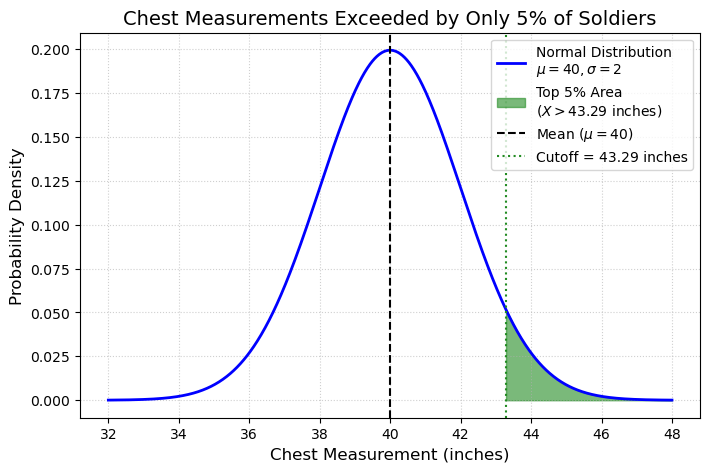

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given parameters
mu = 40          # Mean chest size (in inches)
sigma = 2        # Standard deviation (in inches)
percentile = 0.95 # 95th percentile (exceeded by only 5%)

# Step 1: Calculate the cutoff value using PPF (or inverse Survival Function)
cutoff_value = stats.norm.ppf(percentile, loc=mu, scale=sigma)
# Alternatively: cutoff_value = stats.norm.isf(0.05, loc=mu, scale=sigma)

print(f"Chest measurement exceeded by only 5%: {cutoff_value:.2f} inches")

# Step 2: Plot the probability distribution
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Normal Distribution\n$\\mu={mu}, \\sigma={sigma}$', color='blue', linewidth=2)

# Shade the top 5% tail
x_shade = np.linspace(cutoff_value, mu + 4 * sigma, 500)
y_shade = stats.norm.pdf(x_shade, loc=mu, scale=sigma)
plt.fill_between(x_shade, y_shade, color='forestgreen', alpha=0.6, label=f'Top 5% Area\n($X > {cutoff_value:.2f}$ inches)')

# Add labels and styling
plt.title('Chest Measurements Exceeded by Only 5% of Soldiers', fontsize=14)
plt.xlabel('Chest Measurement (inches)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(mu, color='black', linestyle='--', label=f'Mean ($\\mu = {mu}$)')
plt.axvline(cutoff_value, color='forestgreen', linestyle=':', label=f'Cutoff = {cutoff_value:.2f} inches')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

#### Commentary

The analysis shows that the chest measurement at 43.29 inches is the point at which 5% of Scottish soldiers exceed this chest size.

## Computer activity 2: Errors in angular measurements

In Activities 6 and 7 of Unit 6, a normal distribution with mean 0 and variance 2.75 was used to model angular measurement errors made during the mapping of the state of Massachusetts in the USA in the nineteenth century.

*During the mapping of the state of Massachusetts in the USA in the nineteenth century, 100 readings were taken on the error involved when measuring angles. The data, which are from the United States Survey Report (1854), are represented in Figure 10. The error was measured in minutes of arc. (A minute is 1/60 of a degree.)*

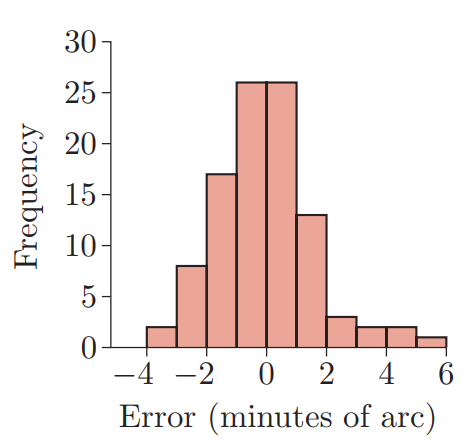

In this activity you should use Minitab to find the probabilities and quantiles discussed in those activities as listed below. (Round the value for the standard deviation that you use to three decimal places.)

(a) Find the probability that an error is positive and greater than 0.5 minutes of arc.<br>
(b) What is the probability that an error is positive but less than two minutes of arc?<br>
(c) Obtain the probability that the size of an error, which may be positive or negative, is less than 1 minute of arc.<br>
(d) What is the probability that the size of an error, positive or negative, is greater than 1.5 minutes of arc?<br>
(e) Suppose that 10% of errors are positive and greater than $x$. Find the value of $x$.<br>
(f) Suppose that 95% of errors lie between −b and b (where b is positive). Find the value of b.<br>
(g) Suppose that 99% of errors lie between −c and c (where c is positive). Find the value of c.<br>

### The probability that an error is positive and greater than 0.5 minutes of arc

The probability can be re-expressed as follows and by calculating the $z$ score with the above formula and taking the compliment we want the shaded region after the value of the random variable $X$ greater than 0.5.

$P(X > 0.5) = P(Z > 0.3015) = 1 - P(Z \le 0.3015)$

Probability P(X > 0.5) = 0.3815 (or 38.15%)


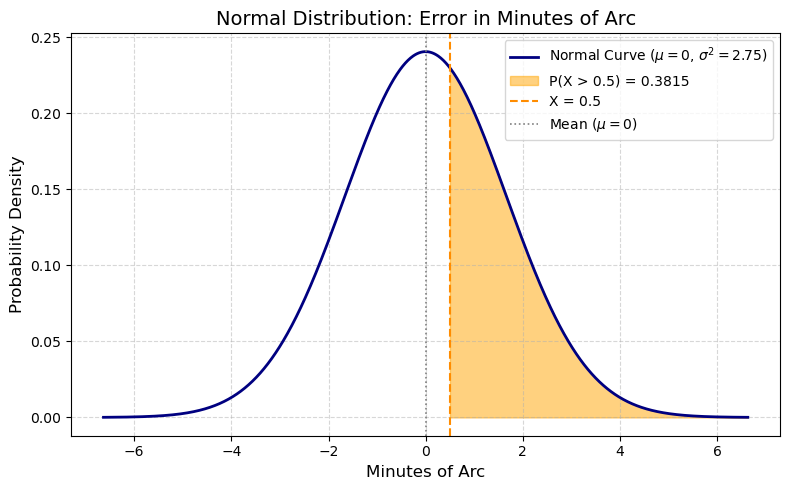

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Define distribution parameters
mu = 0               # Mean
variance = 2.75      # Variance
sigma = np.sqrt(variance)  # Standard deviation
threshold = 0.5      # Measurement threshold (minutes of arc)

# 2. Calculate the probability P(X > 0.5)
# 1 - CDF(threshold) gives the area to the right
prob = 1 - stats.norm.cdf(threshold, loc=mu, scale=sigma)
print(f"Probability P(X > {threshold}) = {prob:.4f} (or {prob * 100:.2f}%)")

# 3. Create data for the bell curve (from -4σ to +4σ)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

# 4. Plot the normal distribution curve
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"Normal Curve ($\mu = {mu}$, $\sigma^2 = {variance}$)", color="navy", lw=2)

# 5. Shade the region where X > 0.5
x_fill = np.linspace(threshold, mu + 4 * sigma, 500)
y_fill = stats.norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.5, label=f"P(X > {threshold}) = {prob:.4f}")

# 6. Add reference lines
plt.axvline(threshold, color="darkorange", linestyle="--", lw=1.5, label=f"X = {threshold}")
plt.axvline(mu, color="gray", linestyle=":", lw=1.2, label=f"Mean ($\mu = {mu}$)")

# 7. Labels and styling
plt.title("Normal Distribution: Error in Minutes of Arc", fontsize=14)
plt.xlabel("Minutes of Arc", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Commentary

The probability that the size of the error (minute of arc) is greater than 0.5 of the observed values is 38.15%

### The probability that an error is positive but less than two minutes of arc

Again the question can be re-expressed as:

$P(0 < X < 2) = P(0 < Z < 1.2060) = P(Z < 1.2060) - P(Z < 0)$

Which means considering $z$ score at 0 and and 2 of the random variable $X$. The difference between these two values gives the area on the curve which gives the required probability that the error is positive i.e. greater than zero and less than two minutes of arc.

Probability P(0 < X < 2) = 0.3861 (or 38.61%)


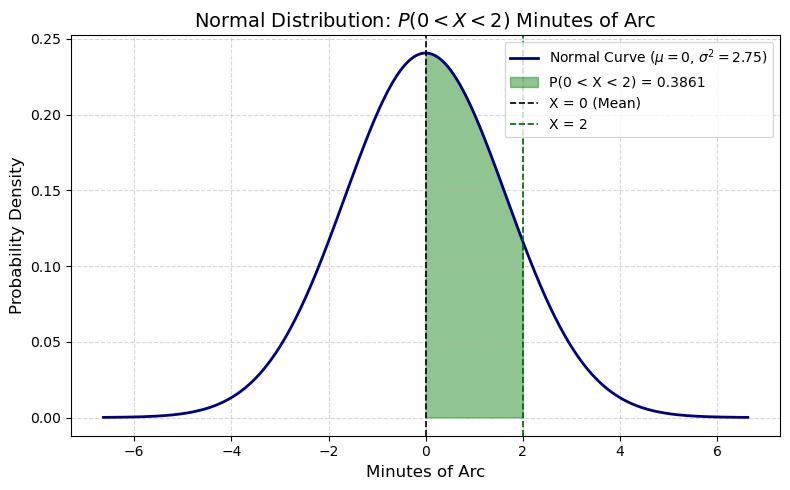

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Define distribution parameters
mu = 0                    # Mean
variance = 2.75           # Variance
sigma = np.sqrt(variance) # Standard deviation

# Boundaries
lower_bound = 0
upper_bound = 2

# 2. Calculate the probability P(0 < X < 2)
p_lower = stats.norm.cdf(lower_bound, loc=mu, scale=sigma)
p_upper = stats.norm.cdf(upper_bound, loc=mu, scale=sigma)
prob = p_upper - p_lower

print(f"Probability P({lower_bound} < X < {upper_bound}) = {prob:.4f} (or {prob * 100:.2f}%)")

# 3. Create x values for the bell curve (from -4σ to +4σ)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

# 4. Plot the normal distribution curve
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"Normal Curve ($\mu = {mu}$, $\sigma^2 = {variance}$)", color="navy", lw=2)

# 5. Shade the region where 0 < X < 2
x_fill = np.linspace(lower_bound, upper_bound, 300)
y_fill = stats.norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color="forestgreen", alpha=0.5, 
                 label=f"P({lower_bound} < X < {upper_bound}) = {prob:.4f}")

# 6. Add vertical lines for boundaries
plt.axvline(lower_bound, color="black", linestyle="--", lw=1.2, label=f"X = {lower_bound} (Mean)")
plt.axvline(upper_bound, color="darkgreen", linestyle="--", lw=1.2, label=f"X = {upper_bound}")

# 7. Labels, title, and legend
plt.title("Normal Distribution: $P(0 < X < 2)$ Minutes of Arc", fontsize=14)
plt.xlabel("Minutes of Arc", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Commentary

The probability that the size of the error (minute of arc) is between 0 and 2 of the observed values is 38.61%

### The probability that the size of an error, which may be positive or negative, is less than 1 minute of arc

So the re-framing is not that the size of an error is less than 1 minute of arc but that it is less than postive 1 minute of arc and greater that negative 1 minute of arc. Hence, the $z$ score at -1 and 1 need to be substracted from each other to find the relevant region under the curve.

$P(|X| < 1) = P(-1 < X < 1) = P(-0.6030 < Z < 0.6030) = P(Z < 0.6030) - P(Z < -0.6030)$

Also, since the normal distribution is perfectly symmetrical the area before -1 and the area after 1 are both the same so we can just express the required area between -1 and 1 as follows:

$P(-0.6030 < Z < 0.6030) = 2 \cdot P(Z < 0.6030) - 1$

Probability P(|X| < 1) = P(-1.0 < X < 1.0) = 0.4535 (or 45.35%)


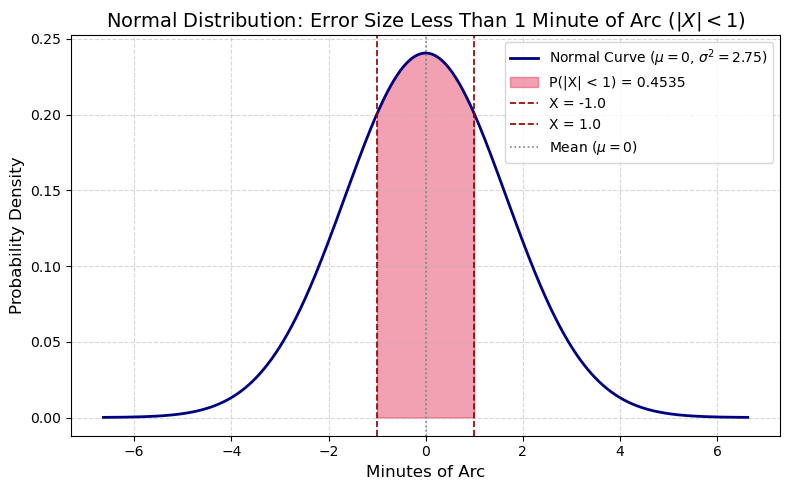

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Define distribution parameters
mu = 0                    # Mean
variance = 2.75           # Variance
sigma = np.sqrt(variance) # Standard deviation

# Absolute error threshold: |X| < 1 => -1 < X < 1
lower_bound = -1.0
upper_bound = 1.0

# 2. Calculate the probability P(-1 < X < 1)
p_lower = stats.norm.cdf(lower_bound, loc=mu, scale=sigma)
p_upper = stats.norm.cdf(upper_bound, loc=mu, scale=sigma)
prob = p_upper - p_lower

print(f"Probability P(|X| < 1) = P({lower_bound} < X < {upper_bound}) = {prob:.4f} (or {prob * 100:.2f}%)")

# 3. Create x values for the bell curve (from -4σ to +4σ)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

# 4. Plot the normal distribution curve
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"Normal Curve ($\mu = {mu}$, $\sigma^2 = {variance}$)", color="navy", lw=2)

# 5. Shade the region where -1 < X < 1
x_fill = np.linspace(lower_bound, upper_bound, 400)
y_fill = stats.norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color="crimson", alpha=0.4, 
                 label=f"P(|X| < 1) = {prob:.4f}")

# 6. Add vertical lines for the boundaries and mean
plt.axvline(lower_bound, color="darkred", linestyle="--", lw=1.2, label=f"X = {lower_bound}")
plt.axvline(upper_bound, color="darkred", linestyle="--", lw=1.2, label=f"X = {upper_bound}")
plt.axvline(mu, color="gray", linestyle=":", lw=1.2, label=f"Mean ($\mu = {mu}$)")

# 7. Labels, title, and styling
plt.title("Normal Distribution: Error Size Less Than 1 Minute of Arc ($|X| < 1$)", fontsize=14)
plt.xlabel("Minutes of Arc", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Commentary

The probability that the size of the error (minute of arc) is between -1 and 1 of the observed values is 45.35%

### What is the probability that the size of an error, positive or negative, is greater than 1.5 minutes of arc?

Re-expressing this means to find the required probability that the error (minute of arc) is greater than positive 1.5 and negative 1.5 so:

$P(|X| > 1.5) = P(X < -1.5) + P(X > 1.5)$